<a href="https://colab.research.google.com/github/tu25003-7491-cyber/EU_M_Math-Repository/blob/main/Chap09_Ex_03_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import numpy.random as random
import scipy as sp
from pandas import Series, DataFrame
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
%matplotlib inline

import sklearn

import requests
import io

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

相関係数:0.889


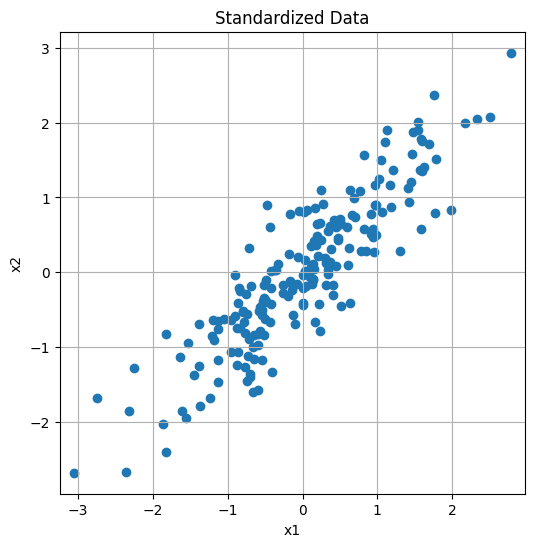

components_属性
[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]

explained_variance_属性
[1.89888438 0.11116588]

explained_variance_ratio_属性
[0.94469498 0.05530502]

主成分分析後のデータ形状
(200, 2)


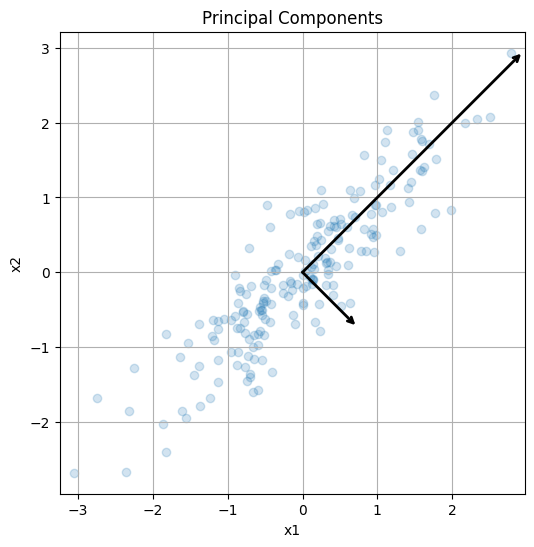

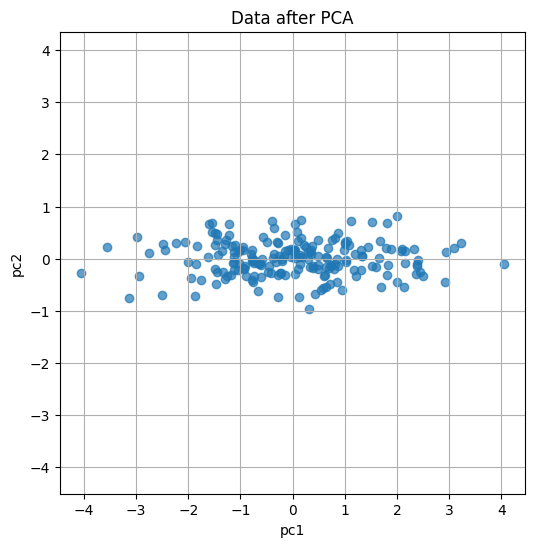

In [6]:
# RandomStateオブジェクトを作成
sample = np.random.RandomState(1)

# 2つの乱数を生成
X = np.dot(sample.rand(2, 2), sample.randn(2, 200)).T

# 標準化
sc = StandardScaler()
X_std = sc.fit_transform(X)

# 相関係数の算出とグラフ化
print('相関係数:{:.3f}'.format(sp.stats.pearsonr(X_std[:, 0], X_std[:, 1])[0]))

plt.figure(figsize=(6, 6))
plt.scatter(X_std[:, 0], X_std[:, 1])
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Standardized Data')
plt.grid(True)
plt.axis('equal')
plt.show()

# 主成分分析
pca = PCA(n_components=2)
pca.fit(X_std)

# 主成分分析後のデータ
X_pca = pca.transform(X_std)

# 学習結果の確認
print('components_属性')
print(pca.components_)

print('\nexplained_variance_属性')
print(pca.explained_variance_)

print('\nexplained_variance_ratio_属性')
print(pca.explained_variance_ratio_)

print('\n主成分分析後のデータ形状')
print(X_pca.shape)

# 主成分ベクトルを図示するための関数
def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops = dict(
        arrowstyle='->',
        linewidth=2,
        shrinkA=0,
        shrinkB=0
    )
    ax.annotate('', v1, v0, arrowprops=arrowprops)

# 元のデータをプロット
plt.figure(figsize=(6, 6))
plt.scatter(X_std[:, 0], X_std[:, 1], alpha=0.2)

# 主成分の向きを矢印で表示
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Principal Components')
plt.grid(True)
plt.axis('equal')
plt.show()

# 主成分分析後のデータをプロット
plt.figure(figsize=(6, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.xlabel('pc1')
plt.ylabel('pc2')
plt.title('Data after PCA')
plt.grid(True)
plt.axis('equal')
plt.show()